In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#Parámetros del sistema.
R  = 6 #Ω
L  = 3 #mH
Ka = 0.02 #V·s/rad
Km = 0.02 #N·m/A
B  = 5e-5 #N·m·s/rad
J  = 1e-5 #kg·m²

# Función de voltaje
def vs(t):
    if t < 1:
        return 0
    else:
        return 12

# Par de carga
def TL(t):
    if t < 5:
        return 0
    else:
        return 0.01

def motorDC(t,x):
    i, w = x
    dot_i = (-R*i - Ka*w + vs(t))/L
    dot_w = (-TL(t) + Km*i - B*w)/J
    return np.array([dot_i,dot_w])


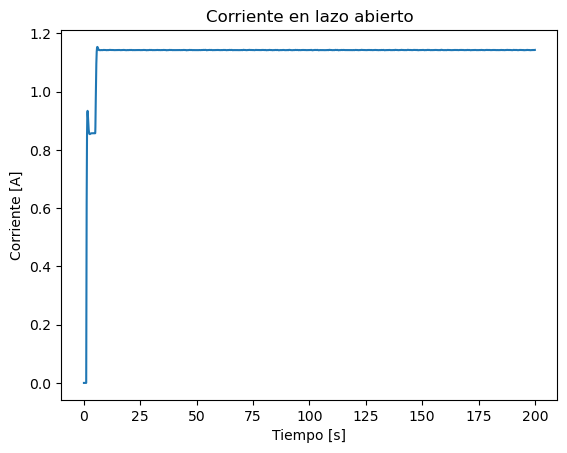

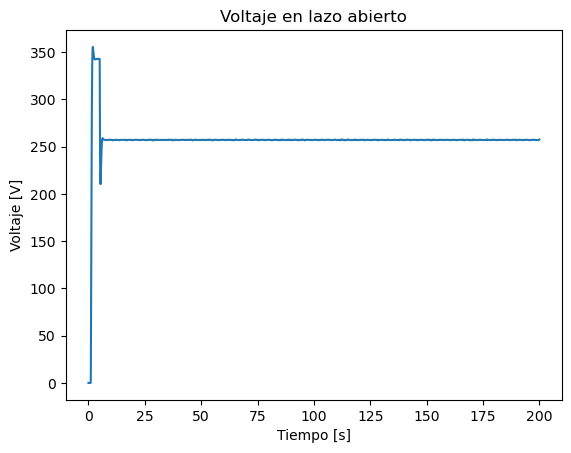

In [165]:
# Lazo abierto
tsim = 200
h = 0.01
tt = np.arange(0,tsim,h)
data_la = solve_ivp(motorDC,(0,tsim),[0,0],t_eval = tt)
plt.figure()
plt.plot(data_la.t,data_la.y[0])
plt.title('Corriente en lazo abierto')
plt.xlabel('Tiempo [s]')
plt.ylabel('Corriente [A]')
plt.show()
plt.figure()
plt.plot(data_la.t,data_la.y[1])
plt.title('Voltaje en lazo abierto')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [V]')
plt.show()

In [166]:
# Lazo cerrado
setpoint = 300
global error_integral, error_anterior
error_integral = 0
error_anterior = 0
def control(t,x):
    global error_integral, error_anterior
    i, w = x
    # Control proporcional
    Kp = 0.0342
    error = setpoint - w
    v_control = Kp*error
    if 1:
        # control proporcional - integral
        Ti  =  1
        Ki = Kp/Ti
        error_integral += error * h
        v_control += Ki * error_integral

    return v_control

def motorDC_lazo_cerrado(t,x):
    i, w = x
    v_control = control(t,x)
    dot_i = (-R*i - Ka*w + v_control)/L
    dot_w = (-TL(t) + Km*i - B*w)/J
    return np.array([dot_i,dot_w])

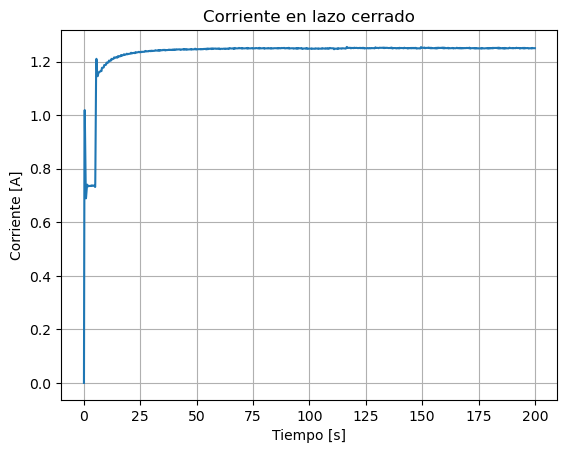

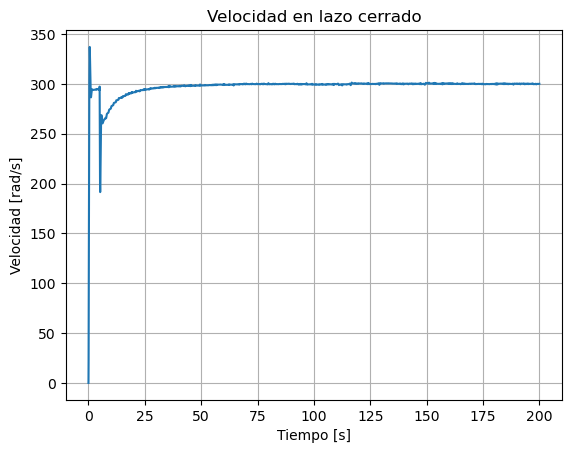

In [167]:
data_lc = solve_ivp(motorDC_lazo_cerrado,(0,tsim),[0,0],t_eval = tt)
plt.figure()
plt.plot(data_lc.t,data_lc.y[0])
plt.title('Corriente en lazo cerrado')
plt.xlabel('Tiempo [s]')
plt.ylabel('Corriente [A]')
plt.grid(True)
plt.show()
plt.figure()
plt.plot(data_lc.t,data_lc.y[1])
plt.title('Velocidad en lazo cerrado')
plt.xlabel('Tiempo [s]')
plt.ylabel('Velocidad [rad/s]')
plt.grid(True)
plt.show()

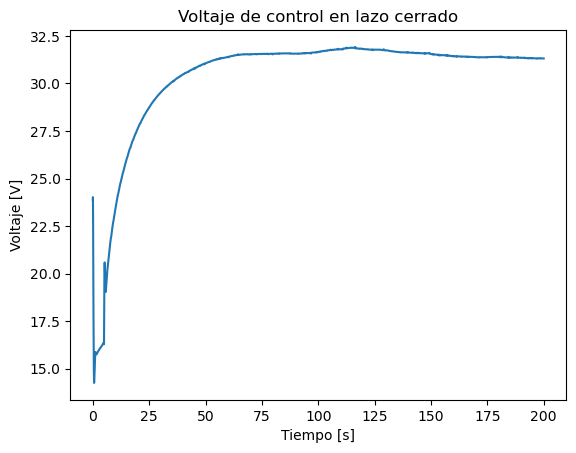

In [168]:
voltaje = [control(t,x) for t,x in zip(data_lc.t,data_lc.y.T)]
plt.figure()
plt.plot(data_lc.t,voltaje)
plt.title('Voltaje de control en lazo cerrado')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [V]')
plt.show()
    

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


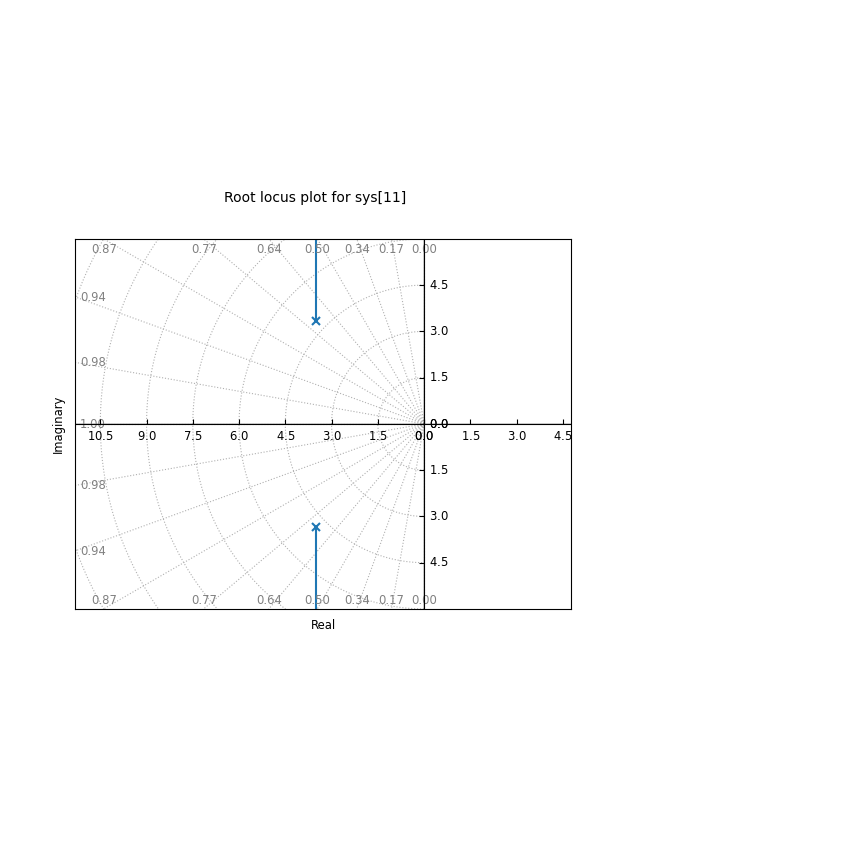

C:\Users\cjuar\AppData\Roaming\Python\Python313\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


In [169]:
# Sintonización de control Proporcional
import control as ct
G = ct.TransferFunction([Km],[J*L, J*R + B*L, B*R + Ka*Km])
ct.rlocus(G)
plt.show()
# datos del lugar de las raices
rlist, klist = ct.rlocus(G, plot=False)



SyntaxError: invalid syntax (720932764.py, line 2)

In [ ]:
rlist

array([[-3.5  -3.32916406j, -3.5  +3.32916406j],
       [-3.5  -3.32916406j, -3.5  +3.32916406j],
       [-3.5  -3.45420723j, -3.5  +3.45420723j],
       [-3.5  -3.57487929j, -3.5  +3.57487929j],
       [-3.5  -3.69160889j, -3.5  +3.69160889j],
       [-3.5  -3.80475892j, -3.5  +3.80475892j],
       [-3.5  -3.9146398j , -3.5  +3.9146398j ],
       [-3.5  -4.02151949j, -3.5  +4.02151949j],
       [-3.5  -4.12563126j, -3.5  +4.12563126j],
       [-3.5  -4.22717963j, -3.5  +4.22717963j],
       [-3.5  -4.3263451j , -3.5  +4.3263451j ],
       [-3.5  -4.42328794j, -3.5  +4.42328794j],
       [-3.5  -4.51815122j, -3.5  +4.51815122j],
       [-3.5  -4.6110633j , -3.5  +4.6110633j ],
       [-3.5  -4.70213984j, -3.5  +4.70213984j],
       [-3.5  -4.7914855j , -3.5  +4.7914855j ],
       [-3.5  -4.87919539j, -3.5  +4.87919539j],
       [-3.5  -4.96535617j, -3.5  +4.96535617j],
       [-3.5  -5.05004715j, -3.5  +5.05004715j],
       [-3.5  -5.13334106j, -3.5  +5.13334106j],
       [-3.5  -5.215